<a href="https://colab.research.google.com/github/xoolmana/AI-ML-PROJECT/blob/main/AI_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining Project Template (GitHub + Colab)
## Anthony Holden
## 4/15/26

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**


In [5]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


# Deliverable 1: Problem Definition and Data Acquisition

## **Dataset Selection**
#### I selected a drug review dataset containing patient experiences with various medications. The dataset includes features such as:

- rating (overall satisfaction)
- effectiveness (numerical rating)
- sideEffects (numerical rating)
- condition (medical condition)
- benefitsReview (text)
- sideEffectsReview (text)
- commentsReview (text)

#### The dataset contains 4,000+ observations, making it suitable for machine learning tasks.

## **Problem Statement**

#### The goal of this project is to predict a patient's overall satisfaction with a drug based on early indicators such as effectiveness, side effects, and condition. This model could help predict patient satisfaction earlier, allowing for better treatment decisions and improved patient outcomes.

## Target Variable

#### The target variable for this project is: **Overall Satisfaction Rating**

## **Use Case / Domain Context**

#### This dataset is in healthcare and pharmaceutical, where patient feedback plays a critical role in evaluating drug performance.

#### This model can be used by:

- Healthcare providers to better understand patient experiences
- Pharmaceutical companies to evaluate drug performance
- Online platforms to automatically summarize or rate drug reviews
- Patients to make more informed decisions when choosing medications

## **Potential Value of the Model**

####The model developed from this dataset could provide several benefits:

- Improved patient insights by summarizing large volumes of reviews
- Faster decision-making for both doctors and patients
- Automated analysis for drug reviews
- Identification of patterns in side effects and effectiveness across conditions


In [6]:
data_url = "https://raw.githubusercontent.com/xoolmana/AI-ML-PROJECT/main/drugLibTrain_raw.tsv"

df = pd.read_csv(data_url, sep='\t')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


In [7]:
df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dysfunction into overt heart failure \r\r\nalone or with other agents in the managment of hypertension \r\r\nmangagement of congestive heart failur,"cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness","monitor blood pressure , weight and asses for resolution of fluid"
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,"Although this type of birth control has more cons than pros, it did help with my cramps. It's also effective with the prevention of pregnancy. (Along with use of condoms as well)","Heavy Cycle, Cramps, Hot Flashes, Fatigue, Long Lasting Cycles. It's only been 5 1/2 months, but i'm concidering changing to a different bc. This is my first time using any kind of bc, unfortunately due to the constant hassel, i'm not happy with the results.","I Hate This Birth Control, I Would Not Suggest This To Anyone."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,"I was used to having cramps so badly that they would leave me balled up in bed for at least 2 days. The Ponstel doesn't take the pain away completely, but takes the edge off so much that normal activities were possible. Definitely a miracle medication!!",Heavier bleeding and clotting than normal.,"I took 2 pills at the onset of my menstrual cramps and then every 8-12 hours took 1 pill as needed for about 3-4 days until cramps were over. If cramps are bad, make sure to take every 8 hours on the dot because the medication stops working suddenly and unfortunately takes about an hour to an hour and a half to kick back in.. if cramps are only moderate, taking every 12 hours is okay."
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,"The acid reflux went away for a few months after just a few days of being on the drug. The heartburn started again as soon as I stopped taking it. So I began treatment again. 6 months passed and I stopped taking it. The heartburn came back, and seemed worse even. The doctor said I should try another 6 month treatment. I did, and the same exact thing happened. This went on for about three years. I asked why this wasn't curing my reflux. The doctor quite frankly told me that it wasn't a cure, but a ""treatment for the symptoms"". I was told that I would probably be on it for the rest of my life.","Constipation, dry mouth and some mild dizziness that would go away after medication was stopped for a few days.","I was given Prilosec prescription at a dose of 45mg per day. Medication was taken once, every morning before eating. Each treatment duration was for 6 months."
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,"I think that the Lyrica was starting to help with the pain, but the side-effects were just too severe to continue.",I felt extremely drugged and dopey. Could not drive at all while on this med. Also had extreme ankle and feet swelling and couldn't even wear shoes.,See above


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

## What to include
- basic shape and structure of the data
- variable types
- missing values
- class balance of the target
- visualizations that help explain the data
- preparation steps you used before modeling

## Suggested questions to resolve
- Are there missing values?
- Are the classes balanced?
- Which variables might be useful predictors?
- Are any variables likely to cause problems?
- Do I need to eliminate any variables due to correlation, redundancy, or uniqueness (ex. id)?


In [8]:
# Basic data inspection
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Shape: (3107, 9)


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dysfunction into overt heart failure \r\r\nalone or with other agents in the managment of hypertension \r\r\nmangagement of congestive heart failur,"cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness","monitor blood pressure , weight and asses for resolution of fluid"
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,"Although this type of birth control has more cons than pros, it did help with my cramps. It's also effective with the prevention of pregnancy. (Along with use of condoms as well)","Heavy Cycle, Cramps, Hot Flashes, Fatigue, Long Lasting Cycles. It's only been 5 1/2 months, but i'm concidering changing to a different bc. This is my first time using any kind of bc, unfortunately due to the constant hassel, i'm not happy with the results.","I Hate This Birth Control, I Would Not Suggest This To Anyone."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,"I was used to having cramps so badly that they would leave me balled up in bed for at least 2 days. The Ponstel doesn't take the pain away completely, but takes the edge off so much that normal activities were possible. Definitely a miracle medication!!",Heavier bleeding and clotting than normal.,"I took 2 pills at the onset of my menstrual cramps and then every 8-12 hours took 1 pill as needed for about 3-4 days until cramps were over. If cramps are bad, make sure to take every 8 hours on the dot because the medication stops working suddenly and unfortunately takes about an hour to an hour and a half to kick back in.. if cramps are only moderate, taking every 12 hours is okay."
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,"The acid reflux went away for a few months after just a few days of being on the drug. The heartburn started again as soon as I stopped taking it. So I began treatment again. 6 months passed and I stopped taking it. The heartburn came back, and seemed worse even. The doctor said I should try another 6 month treatment. I did, and the same exact thing happened. This went on for about three years. I asked why this wasn't curing my reflux. The doctor quite frankly told me that it wasn't a cure, but a ""treatment for the symptoms"". I was told that I would probably be on it for the rest of my life.","Constipation, dry mouth and some mild dizziness that would go away after medication was stopped for a few days.","I was given Prilosec prescription at a dose of 45mg per day. Medication was taken once, every morning before eating. Each treatment duration was for 6 months."
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,"I think that the Lyrica was starting to help with the pain, but the side-effects were just too severe to continue.",I felt extremely drugged and dopey. Could not drive at all while on this med. Also had extreme ankle and feet swelling and couldn't even wear shoes.,See above


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,3107.0,NaN,NaN,NaN,2080.607016,1187.998828,0.0,1062.5,2092.0,3092.5,4161.0
urlDrugName,3107,502,lexapro,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,3107.0,NaN,NaN,NaN,7.006115,2.937582,1.0,5.0,8.0,9.0,10.0
effectiveness,3107,5,Highly Effective,1330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffects,3107,5,Mild Side Effects,1019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,3106,1426,depression,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefitsReview,3089,3031,none,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffectsReview,3032,2813,none,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commentsReview,3095,3046,none,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
display(missing_summary)


,0
sideEffectsReview,75
benefitsReview,18
commentsReview,12
condition,1


In [10]:
# TODO: Replace with your actual target column name
target = "rating"

# Class balance
display(df[target].value_counts(dropna=False))
display(df[target].value_counts(normalize=True, dropna=False))


,count
rating,
10,742
8,558
9,480
7,350
1,305
5,159
6,157
3,146
4,107


,proportion
rating,
10,0.238816
8,0.179594
9,0.154490
7,0.112649
1,0.098165
5,0.051175
6,0.050531
3,0.046991
4,0.034438


## AutoViz integration

AutoViz is useful for fast exploratory analysis. It can generate many plots at once.

**Important for Colab:** after AutoViz runs, use `plt.close('all')` before creating your own plots later in the notebook. This helps prevent old figures from appearing unexpectedly.


In [11]:
# Install and run AutoViz in Colab if needed
# You may comment this out if AutoViz is already installed in your runtime

# !pip install autoviz

from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()


In [12]:
# AutoViz example
# Replace target with your real target column name before running
dfte = AV.AutoViz(
     "",
     sep=",",
     depVar=target,
     dfte=df,
     header=0,
     verbose=1,
     lowess=False,
     chart_format="svg",
     max_rows_analyzed=150000,
     max_cols_analyzed=30
 )

# Clear any queued figures after AutoViz so later plots behave normally in Colab
import matplotlib.pyplot as plt
plt.close('all')


Shape of your Data Set loaded: (3107, 9)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  0
    Number of String-Categorical Columns =  2
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  1
    Number of NLP String Columns =  4
    Number of Date Time Columns =  0
    Number of ID Columns =  1
    Number of Columns to Delete =  0
    8 Predictors classified...
        1 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['Unnamed: 0']

################ Multi_Classification problem ########

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
urlDrugName,object,0.000000,16,,,Possible high cardinality column with 502 unique values: Use hash encoding or text embedding to reduce dimension.
effectiveness,object,0.000000,0,,,No issue
sideEffects,object,0.000000,0,,,No issue
condition,object,0.032510,46,,,"1 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
benefitsReview,object,0.585176,98,,,"18 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
sideEffectsReview,object,2.405722,91,,,"74 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
commentsReview,object,0.390117,99,,,"12 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
rating,int64,0.000000,0,1.000000,10.000000,Target column. Appears to have Imbalanced classes. Try balancing classes.


No continuous var in data set: drawing categorical distribution plots


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

Could not draw wordcloud plot for benefitsReview. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Could not draw wordcloud plot for sideEffectsReview. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Could not draw wordcloud plot for commentsReview. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download t

[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | 
[nltk_data]  Done downloading collection popular


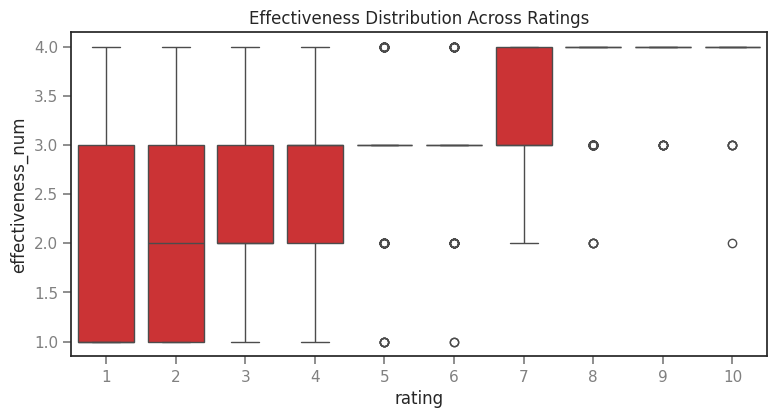

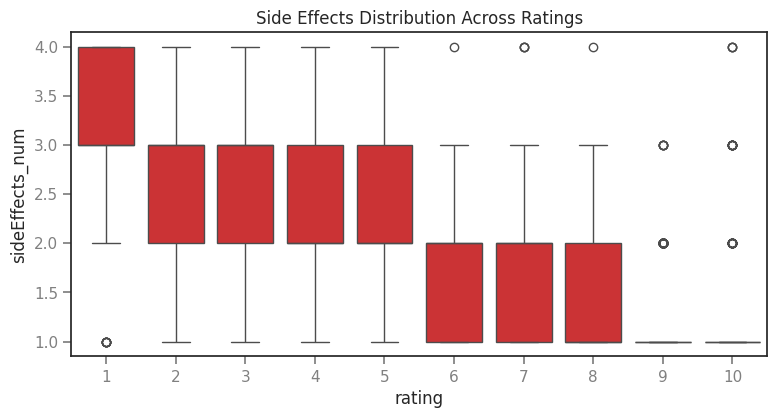

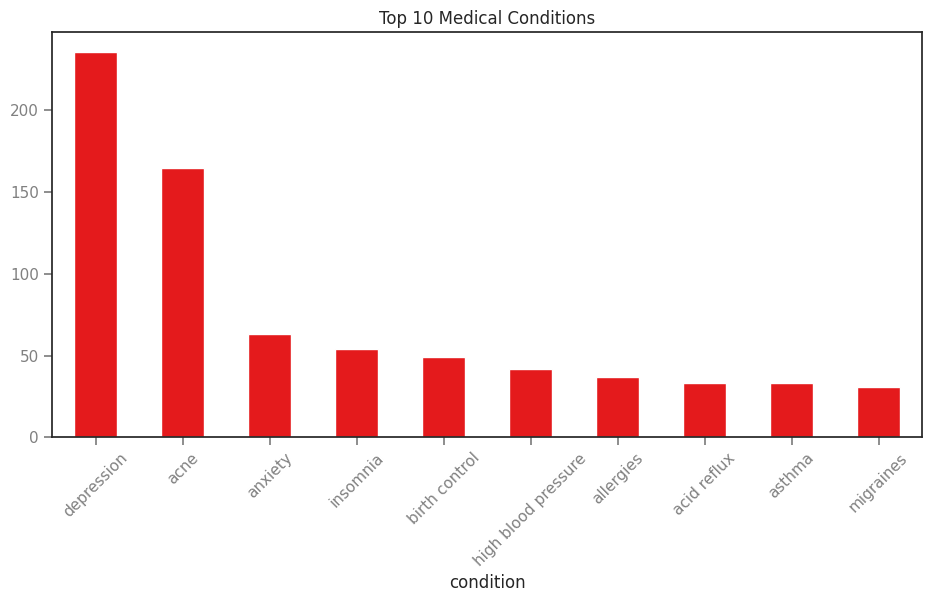

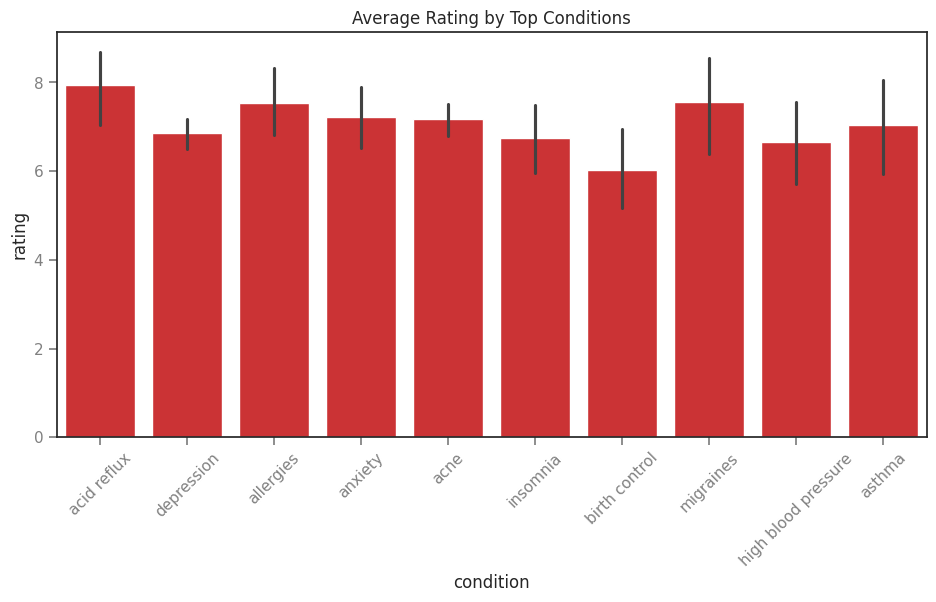

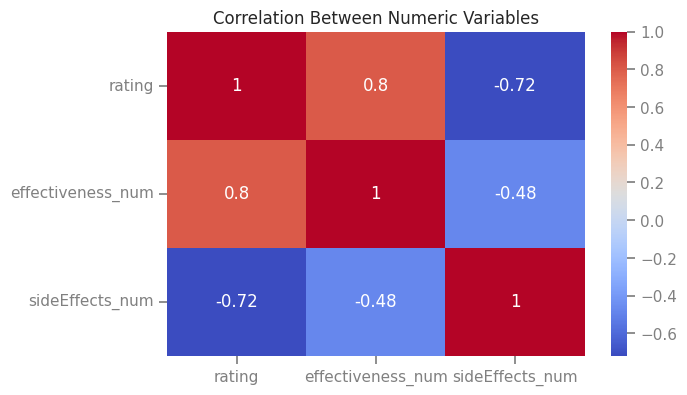

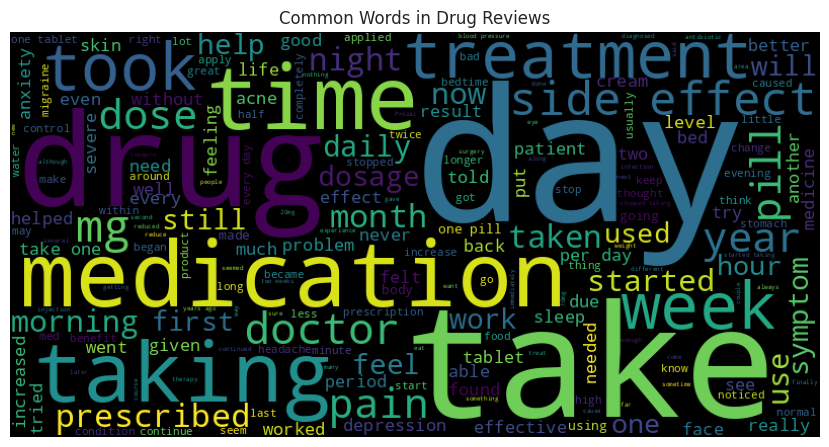

In [13]:
effectiveness_map = {
    "Ineffective": 1,
    "Marginally Effective": 2,
    "Moderately Effective": 3,
    "Highly Effective": 4
}

sideeffects_map = {
    "Mild Side Effects": 1,
    "Moderate Side Effects": 2,
    "Severe Side Effects": 3,
    "Extremely Severe Side Effects": 4
}

df['effectiveness_num'] = df['effectiveness'].map(effectiveness_map)
df['sideEffects_num'] = df['sideEffects'].map(sideeffects_map)


top_conditions = df['condition'].value_counts().head(10).index
filtered = df[df['condition'].isin(top_conditions)]

# Code for custom visualiations (optional)

%matplotlib inline

# target distribution
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='rating', y='effectiveness_num')
plt.title("Effectiveness Distribution Across Ratings")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='rating', y='sideEffects_num')
plt.title("Side Effects Distribution Across Ratings")
plt.show()

plt.figure(figsize=(10,5))
df['condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Medical Conditions")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=filtered, x='condition', y='rating', estimator='mean')
plt.title("Average Rating by Top Conditions")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df[['rating','effectiveness_num','sideEffects_num']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Variables")
plt.show()

from wordcloud import WordCloud

text = " ".join(df['commentsReview'].dropna().astype(str))
wc = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Common Words in Drug Reviews")
plt.show()

### Summary
Overall, the dataset required moderate preprocessing, including handling categorical variables, and preparing features for machine learning models. These steps makes sure the data is in a usable format for training  models to predict the overall drug satisfaction.

# Deliverable 3: Model Development, Evaluation & Interpretation



In [14]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score
)


In [15]:
# Identify feature columns
X = df.drop(columns=[target])
y = df[target]

# If needed, convert target labels here
# Example:
# y = y.map({"No": 0, "Yes": 1})

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['urlDrugName', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']
Numeric columns: ['Unnamed: 0', 'effectiveness_num', 'sideEffects_num']


In [16]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)


In [17]:
# Baseline Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Cohen's Kappa:", round(cohen_kappa_score(y_test, y_pred), 4))


Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.58      0.85      0.69        61
           2       0.00      0.00      0.00        21
           3       0.24      0.28      0.26        29
           4       0.22      0.10      0.13        21
           5       0.06      0.03      0.04        32
           6       0.19      0.10      0.13        31
           7       0.41      0.27      0.33        70
           8       0.42      0.69      0.52       112
           9       0.29      0.07      0.12        96
          10       0.63      0.85      0.72       149

    accuracy                           0.47       622
   macro avg       0.30      0.32      0.29       622
weighted avg       0.41      0.47      0.41       622

Cohen's Kappa: 0.3705


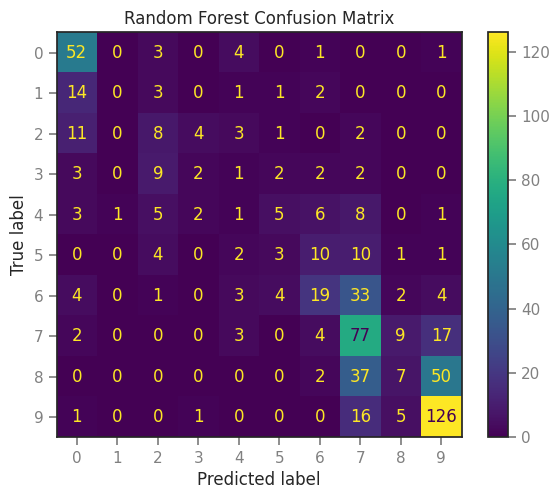

In [18]:
# Confusion matrix
import matplotlib.pyplot as plt

plt.close('all')
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.show()


In [20]:
# Tune the Random Forest model
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [21]:
# Final evaluation on the test set
best_preds = best_rf.predict(X_test)

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_preds))

kappa = cohen_kappa_score(y_test, best_preds)
print("Cohen's Kappa:", round(kappa, 4))


Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.58      0.85      0.69        61
           2       0.00      0.00      0.00        21
           3       0.24      0.28      0.26        29
           4       0.22      0.10      0.13        21
           5       0.06      0.03      0.04        32
           6       0.19      0.10      0.13        31
           7       0.41      0.27      0.33        70
           8       0.42      0.69      0.52       112
           9       0.29      0.07      0.12        96
          10       0.63      0.85      0.72       149

    accuracy                           0.47       622
   macro avg       0.30      0.32      0.29       622
weighted avg       0.41      0.47      0.41       622

Cohen's Kappa: 0.3705


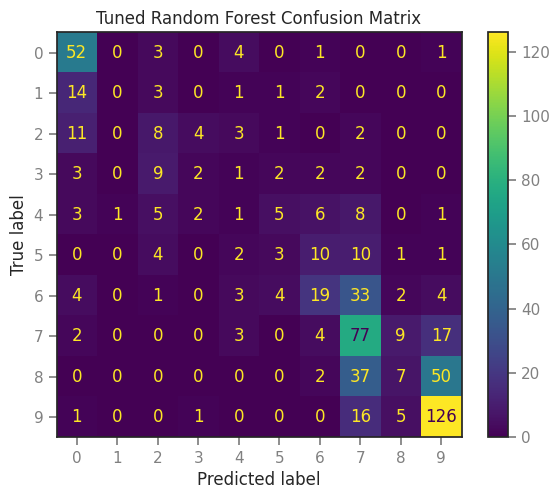

In [22]:
# Tuned confusion matrix
plt.close('all')
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix")
plt.show()


In [23]:
# Feature importance from the tuned model
import pandas as pd

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))


,feature,importance
462,cat__effectiveness_Highly Effective,0.037476
1,num__effectiveness_num,0.028343
461,cat__effectiveness_Considerably Effective,0.023803
0,num__Unnamed: 0,0.022990
2,num__sideEffects_num,0.022598
463,cat__effectiveness_Ineffective,0.018118
469,cat__sideEffects_No Side Effects,0.016149
468,cat__sideEffects_Moderate Side Effects,0.014954
466,cat__sideEffects_Extremely Severe Side Effects,0.011375
465,cat__effectiveness_Moderately Effective,0.011261


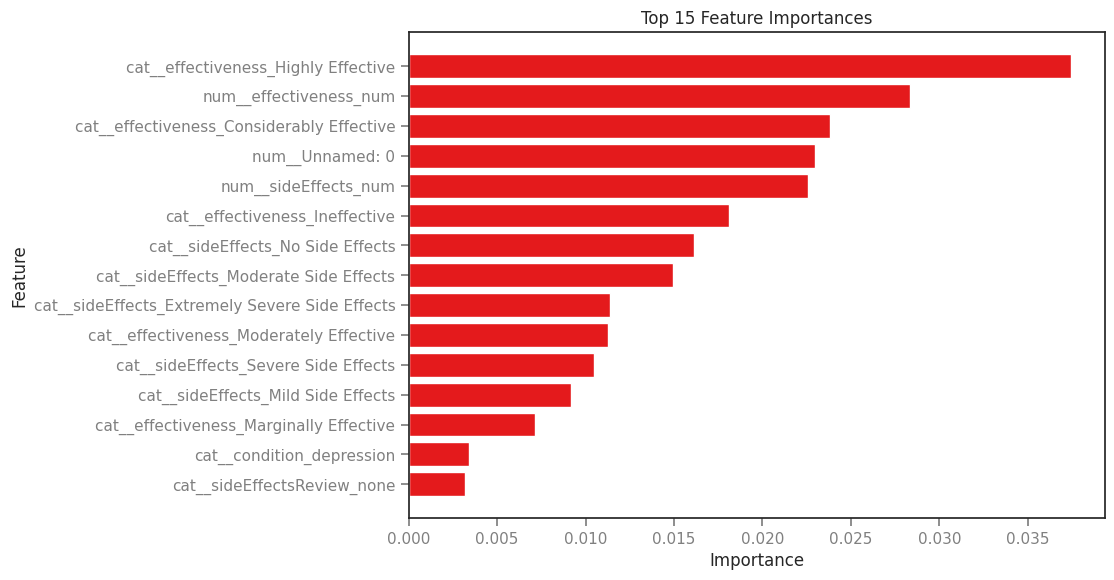

In [24]:
# Plot top feature importances
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Summary

The Random Forest model performed well overall and achieved strong results across evaluation metrics such as accuracy, precision, recall, and F1-score. Out of the models tested, it provided the best balance between predictive performance and reliability, it was effective at learning patterns in patient satisfaction ratings. The model was generally better at predicting rating classes that appeared more frequently in the dataset, while less common ratings were more difficult to classify accurately. It also had more trouble with middle-range ratings, since those can overlap with both positive and negative patient experiences.

The most important variables were effectiveness and sideEffects because they directly reflect how patients responded to the medication. The condition feature was also useful, since certain drugs may perform differently depending on the health issue being treated. Most model mistakes happened when predicting similar rating values, such as confusing a rating of 7 with 8, or when a review had mixed signals like high effectiveness but severe side effects.

This model could be useful for healthcare providers, pharmaceutical companies, and online review platforms. It could help predict patient satisfaction earlier, identify medication trends, and summarize large amounts of review data more efficiently. If I continued improving the project, I would add natural language processing for the written review columns, perform more hyperparameter tuning, and explore additional ways to improve prediction accuracy on less common classes.